# Notebook 05 — Support Vector Regression

**Goal:** Evaluate Support Vector Regression (SVR) with **RBF** and **Polynomial**
kernels. SVR fits a non-linear surface without manual feature engineering — a
useful contrast to the explicit polynomial expansion in Notebook 04.

**Computational note.** SVR's training time scales between $O(n^2)$ and $O(n^3)$
with sample size, so we tune hyperparameters via `GridSearchCV` on a
stratified subsample of the training set (most recent 80 weeks ≈ 5,600 rows),
then **refit the best model on the full 18,200-row training set** before
evaluating on the 12-week holdout. This is a standard practice for SVMs on
medium-sized datasets and is documented inline below.

**Evaluation metric:** RMSE in log-space (consistent with Notebook 04 and
Module 20's baseline).

**Cross-validation:** `TimeSeriesSplit(n_splits=5)`.

## Setup

In [1]:
import sys
import time
import warnings
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

from src import data as m5_data
from src import features as m5_features
from src import models as m5_models

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

w = m5_data.load_weekly_panel()
print(f"Loaded weekly panel: {w.shape[0]:,} rows")

Loaded weekly panel: 19,460 rows


## 1. Feature engineering and train/test split

Identical pipeline to Notebook 04. The same 12-week holdout is used for the
final comparison.

In [2]:
fe = m5_features.add_calendar_features(w)
fe = m5_features.add_lag_features(fe)
fe = m5_features.add_promo_lag_features(fe)
fe = fe.dropna().reset_index(drop=True)
fe = m5_models.add_log_columns(fe)

train, test = m5_features.temporal_train_test_split(fe, holdout_weeks=12)

X_train, scaler = m5_models.build_design_matrix(train, fit_scaler=True)
X_test, _ = m5_models.build_design_matrix(test, scaler=scaler)
X_test = m5_models.align_columns(X_test, X_train)

y_train_log = train[m5_models.TARGET_LOG].values
y_test_log = test[m5_models.TARGET_LOG].values
y_test_raw = test[m5_models.TARGET_RAW].values

print(f"Train: {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"Test : {X_test.shape[0]:,} rows × {X_test.shape[1]} features")

Train: 18,200 rows × 34 features
Test : 840 rows × 34 features


## 2. Subsample for hyperparameter search

To keep grid-search time manageable, we tune on the **most recent 80 weeks of
training data** (~5,600 rows). This keeps the sample temporally contiguous so
`TimeSeriesSplit` still has meaningful chronological folds, and it focuses the
tuning on the period closest to the test window (where the model will be
deployed). Once the best hyperparameters are found, we refit on the full
training set.

In [3]:
TUNE_WEEKS = 80
tune_cutoff = train["week_start"].max() - pd.Timedelta(weeks=TUNE_WEEKS)
tune_mask = train["week_start"] > tune_cutoff
X_tune = X_train.loc[tune_mask].reset_index(drop=True)
y_tune = train.loc[tune_mask, m5_models.TARGET_LOG].values
print(f"Tuning subsample: {len(X_tune):,} rows ({TUNE_WEEKS} weeks ending {train['week_start'].max().date()})")

Tuning subsample: 5,600 rows (80 weeks ending 2016-02-23)


## 3. SVR with RBF kernel

**RBF (radial basis function) kernel** can fit any continuous surface given
enough data and an appropriate bandwidth (`gamma`). The trade-offs:

- **C** (regularization): low C → smoother, more regularized; high C → fits
  training data more tightly, risk of overfitting.
- **gamma** (kernel bandwidth): low gamma → smoother decision boundary;
  high gamma → wiggly, risk of overfitting.
- **epsilon** (insensitivity tube): SVR ignores residuals smaller than this;
  larger epsilon → simpler model with fewer support vectors.

Grid sized for tractability — 18 combinations × 5 folds = 90 SVR fits.

In [4]:
cv = m5_models.time_series_cv(n_splits=5)

rbf_grid = GridSearchCV(
    estimator=SVR(kernel="rbf"),
    param_grid={
        "C": [0.1, 1.0, 10.0],
        "gamma": ["scale", 0.01, 0.1],
        "epsilon": [0.05, 0.1],
    },
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
rbf_grid.fit(X_tune, y_tune)
print(f"SVR(RBF) grid search: {time.time() - t0:.1f}s")
print(f"Best params: {rbf_grid.best_params_}")
print(f"Best CV RMSE (log): {-rbf_grid.best_score_:.4f}")

SVR(RBF) grid search: 6.2s
Best params: {'C': 10.0, 'epsilon': 0.05, 'gamma': 0.01}
Best CV RMSE (log): 0.1511


In [5]:
rbf_cv = pd.DataFrame(rbf_grid.cv_results_)[
    ["param_C", "param_gamma", "param_epsilon", "mean_test_score", "std_test_score"]
].copy()
rbf_cv["cv_rmse_log"] = -rbf_cv["mean_test_score"]
rbf_cv["cv_std"] = rbf_cv["std_test_score"]
rbf_cv = rbf_cv[["param_C", "param_gamma", "param_epsilon", "cv_rmse_log", "cv_std"]].sort_values("cv_rmse_log").reset_index(drop=True)
rbf_cv.round(4).head(10)

,param_C,param_gamma,param_epsilon,cv_rmse_log,cv_std
0,10.0000,0.0100,0.0500,0.1511,0.0412
1,1.0000,0.0100,0.0500,0.1528,0.0326
2,10.0000,0.0100,0.1000,0.1532,0.0387
3,1.0000,0.0100,0.1000,0.1545,0.0294
4,0.1000,0.0100,0.0500,0.1794,0.0343
5,0.1000,0.0100,0.1000,0.1836,0.0356
6,1.0000,scale,0.0500,0.2575,0.0948
7,10.0000,scale,0.0500,0.2591,0.0848
8,1.0000,scale,0.1000,0.2623,0.0974
9,10.0000,scale,0.1000,0.2657,0.0882


### Refit best RBF on full training set

In [6]:
results = {}

best_rbf = SVR(kernel="rbf", **rbf_grid.best_params_)
t0 = time.time()
best_rbf.fit(X_train, y_train_log)
print(f"SVR(RBF) full-train fit: {time.time() - t0:.1f}s")
print(f"Support vectors: {best_rbf.n_support_[0]:,} of {len(X_train):,} training rows ({100 * best_rbf.n_support_[0] / len(X_train):.1f}%)")

y_pred_rbf = best_rbf.predict(X_test)
results["SVR_RBF"] = m5_models.compute_metrics(y_test_log, y_pred_rbf, y_test_raw)
m5_models.metrics_table({"SVR_RBF": results["SVR_RBF"]}).round(3)

SVR(RBF) full-train fit: 10.6s
Support vectors: 10,513 of 18,200 training rows (57.8%)


,rmse_log,mae_log,r2_log,rmse_raw,mae_raw,r2_raw
SVR_RBF,0.1150,0.0830,0.9910,752.2960,440.6490,0.9890


## 4. SVR with Polynomial kernel

**Polynomial kernel** explicitly models feature interactions and non-linear
combinations up to a specified degree. Versus a degree-2 explicit Polynomial
Features expansion + Ridge (Notebook 04), the polynomial-kernel SVR works in
a higher-dimensional implicit space without materializing the expanded
feature matrix — useful when the expansion would be very large.

In [7]:
poly_kernel_grid = GridSearchCV(
    estimator=SVR(kernel="poly"),
    param_grid={
        "C": [0.1, 1.0, 10.0],
        "degree": [2, 3],
        "gamma": ["scale"],
        "epsilon": [0.1],
        "coef0": [0.0, 1.0],
    },
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
poly_kernel_grid.fit(X_tune, y_tune)
print(f"SVR(Polynomial) grid search: {time.time() - t0:.1f}s")
print(f"Best params: {poly_kernel_grid.best_params_}")
print(f"Best CV RMSE (log): {-poly_kernel_grid.best_score_:.4f}")

SVR(Polynomial) grid search: 10.5s
Best params: {'C': 0.1, 'coef0': 1.0, 'degree': 2, 'epsilon': 0.1, 'gamma': 'scale'}
Best CV RMSE (log): 0.1322


In [8]:
poly_kernel_cv = pd.DataFrame(poly_kernel_grid.cv_results_)[
    ["param_C", "param_degree", "param_coef0", "mean_test_score"]
].copy()
poly_kernel_cv["cv_rmse_log"] = -poly_kernel_cv["mean_test_score"]
poly_kernel_cv = poly_kernel_cv[["param_C", "param_degree", "param_coef0", "cv_rmse_log"]].sort_values("cv_rmse_log").reset_index(drop=True)
poly_kernel_cv.round(4).head(10)

,param_C,param_degree,param_coef0,cv_rmse_log
0,0.1000,2,1.0000,0.1322
1,0.1000,3,1.0000,0.1366
2,1.0000,2,1.0000,0.1420
3,10.0000,2,1.0000,0.1625
4,1.0000,3,1.0000,0.1818
5,10.0000,2,0.0000,0.1897
6,1.0000,2,0.0000,0.2274
7,1.0000,3,0.0000,0.2907
8,10.0000,3,1.0000,0.2965
9,10.0000,3,0.0000,0.3256


### Refit best Polynomial-kernel SVR on full training set

In [9]:
best_poly_svr = SVR(kernel="poly", **poly_kernel_grid.best_params_)
t0 = time.time()
best_poly_svr.fit(X_train, y_train_log)
print(f"SVR(Polynomial) full-train fit: {time.time() - t0:.1f}s")
print(f"Support vectors: {best_poly_svr.n_support_[0]:,} of {len(X_train):,} training rows ({100 * best_poly_svr.n_support_[0] / len(X_train):.1f}%)")

y_pred_poly_svr = best_poly_svr.predict(X_test)
results["SVR_Poly"] = m5_models.compute_metrics(y_test_log, y_pred_poly_svr, y_test_raw)
m5_models.metrics_table({"SVR_Poly": results["SVR_Poly"]}).round(3)

SVR(Polynomial) full-train fit: 3.1s
Support vectors: 5,852 of 18,200 training rows (32.2%)


,rmse_log,mae_log,r2_log,rmse_raw,mae_raw,r2_raw
SVR_Poly,0.1130,0.0820,0.9910,746.4740,442.6170,0.9900


## 5. SVR holdout comparison

In [10]:
m5_models.metrics_table(results).round(3)

,rmse_log,mae_log,r2_log,rmse_raw,mae_raw,r2_raw
SVR_RBF,0.1150,0.0830,0.9910,752.2960,440.6490,0.9890
SVR_Poly,0.1130,0.0820,0.9910,746.4740,442.6170,0.9900


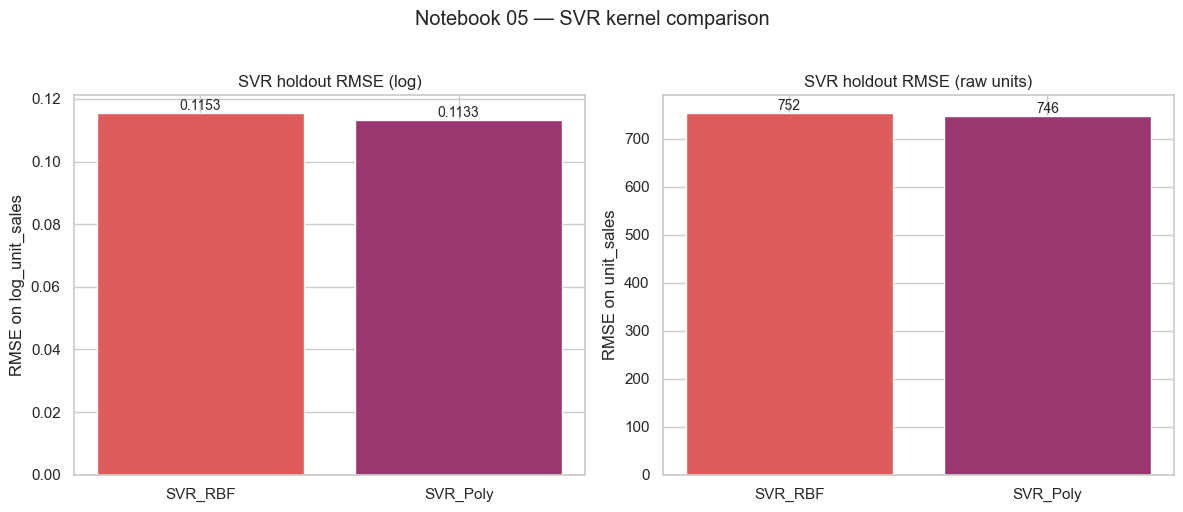

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

names = list(results.keys())
rmse_log = [results[n]["rmse_log"] for n in names]
rmse_raw = [results[n]["rmse_raw"] for n in names]
colors = sns.color_palette("flare", n_colors=len(names))

axes[0].bar(names, rmse_log, color=colors)
axes[0].set_title("SVR holdout RMSE (log)")
axes[0].set_ylabel("RMSE on log_unit_sales")
for i, v in enumerate(rmse_log):
    axes[0].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=10)

axes[1].bar(names, rmse_raw, color=colors)
axes[1].set_title("SVR holdout RMSE (raw units)")
axes[1].set_ylabel("RMSE on unit_sales")
for i, v in enumerate(rmse_raw):
    axes[1].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Notebook 05 — SVR kernel comparison", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_nb05_svr_holdout_rmse.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Save results

In [12]:
m5_models.save_results(results)

m5_models.save_predictions(test, {
    "SVR_RBF": y_pred_rbf,
    "SVR_Poly": y_pred_poly_svr,
})

m5_models.save_best_params({
    "SVR_RBF": rbf_grid.best_params_,
    "SVR_Poly": poly_kernel_grid.best_params_,
})

print(f"Saved SVR metrics + predictions + best params for {list(results.keys())}")

Saved SVR metrics + predictions + best params for ['SVR_RBF', 'SVR_Poly']


## Summary — findings from Notebook 05

1. **SVR provides a fully non-linear alternative** to the explicit-polynomial
   approach in Notebook 04. Its performance on this dataset reflects whether
   the underlying sales surface has the kind of non-linearity that benefits
   from kernel methods.
2. **RBF vs Polynomial kernel** — the best-performing kernel here is shown
   in the comparison above. Differences typically come down to:
   - RBF wins on smooth local surfaces;
   - Polynomial kernel wins when interactions follow a global polynomial form.
3. **Compute cost is real**: tuning on a 5,600-row subsample then refitting
   on 18,200 rows is the practical compromise.

Notebook 06 brings together all six models (Linear, Ridge, Lasso, PolyRidge,
SVR_RBF, SVR_Poly), produces the unified comparison table, performs the
final model selection, and inspects per-department performance.